In [1]:
from utils import * 
import numpy as np
import shutil 
from matplotlib.lines import Line2D
from datetime import datetime
import itertools
import os
import re
import orjson
import ast  
import shutil 
import networkx as nx 
from ppi import get_contacts, get_contact_graph, plot_contact_graph, get_contacts_pooled
import ast 

%load_ext autoreload 
%autoreload 2



# Protein-protein interactions


In [2]:
msa_dir_path = '../data/genes/mmseqs/'

def get_msas_unpaired(gene_ids:list, dir_path:str=msa_dir_path):
    '''Load the unpaired MSAs for the specified gene IDs.
    
    :param gene_ids: The IDs of the genes to construct paired MSAs for. These should all be from the same genome.   
    :param dir_path: The path to the directory where the MSAs are stored. This function assumes the a3m files have names matching the gene ID of the query 
        sequence. 
    '''
    paths = {gene_id:os.path.join(dir_path, f'{gene_id}.a3m') for gene_id in gene_ids}
    paths = {gene_id:path for gene_id, path in paths.items() if os.path.exists(path)}
    return {gene_id:str(FASTAFile.from_file(path)) for gene_id, path in paths.items()}
 

## Conserved cluster protein-protein interactions

We identified a set of 9 gene clusters present in 8 or more of the Betazoid genomes (the "level 1" conserved clusters), and 5 gene clusters present in 5 to 7 of the Betazoid genomes (the "level 2" conserved clusters). Here, we aim to assess which of these conserved proteins may interact by co-folding representatives from each conserved cluster within each genome.

In [3]:
use_custom_msas = False

In [4]:
level_1_conserved_cluster_ids = [8, 7, 0, 4, 5, 6, 1, 3, 2]
level_2_conserved_cluster_ids = [9, 12, 10, 13, 11]

conserved_cluster_ids = level_1_conserved_cluster_ids + level_2_conserved_cluster_ids

In [5]:
alphafold_input_dir = f'../data/genes/alphafold/af_input/ppi-conserved_clusters'
alphafold_output_dir = f'../data/genes/alphafold/af_output/ppi-conserved_clusters' 
os.makedirs(alphafold_input_dir, exist_ok=True)

# Configure the AlphaFold3 job, using fewer diffusion samples and recycles to reduce runtime. 
alphafold_params = dict()
alphafold_params['--num_diffusion_samples'] = 1 # Number of diffusion samples to generate, 5 by default. 
alphafold_params['--num_recycles'] = 5 # Number of recycles to use during inference (refinement steps). 10 by default, dropped here to mitigate runtime. 

In [6]:
genes_df = pd.read_csv('../data/genes/genes.csv', index_col=0)
genes_df['cluster_id'] = genes_df.index.map(json.load(open('../data/genes/clusters.json', 'r')))
genes_df = genes_df[genes_df.cluster_id.isin(conserved_cluster_ids)].copy()

for genome_id, df in genes_df.groupby('genome_id'):
    pairs = list(itertools.combinations(df.reset_index(names='gene_id').to_dict(orient='records'), 2))
    pairs += [(entry, entry) for entry in df.reset_index(names='gene_id').to_dict(orient='records')] # Also add homo-dimers, which are not included in combinations. 

print(f'Number of genes:', len(genes_df))
print(f'Number of gene pairs:', len(pairs))

if use_custom_msas:
    msas = get_msas_unpaired(genes_df.index)
    print('Number of genes with custom MSAs:', len(msas))
    assert len(msas) == len(genes_df), f'All of the conserved gene clusters should have a custom MSA in {msa_dir_path}'

Number of genes: 124
Number of gene pairs: 105


In [7]:
for pair in pairs:
    gene_ids = [pair[0]['gene_id'], pair[1]['gene_id']]
    seqs = [pair[0]['seq'], pair[1]['seq']] 

    name = '-'.join(gene_ids)
    input = AlphaFoldInputFile(name, dialect='alphafold3', num_seeds=3, version=2) # Use 3 seeds rather than the default 5 to reduce runtime.

    for gene_id, seq in zip(gene_ids, seqs):
        unpaired_msa = msas.get(gene_id, None) if use_custom_msas else None
        paired_msa = '' if (unpaired_msa is not None) else None
        input.add_seq(seq, paired_msa=paired_msa, unpaired_msa=unpaired_msa)

    input.write(os.path.join(alphafold_input_dir, f'{name}.json'))

cmd = [f'run_alphafold3 --input_dir=/root/af_input/{os.path.basename(alphafold_input_dir)}/ --model_dir=/root/models --db_dir=/root/public_databases --output_dir=/root/af_output']
cmd += [f'{param} {value}' for param, value in alphafold_params.items()]
cmd = ' '.join(cmd)
cmd = f'sbatch --partition gpu --gpus 1 --wrap "{cmd}"'
print(cmd)

sbatch --partition gpu --gpus 1 --wrap "run_alphafold3 --input_dir=/root/af_input/ppi-conserved_clusters/ --model_dir=/root/models --db_dir=/root/public_databases --output_dir=/root/af_output --num_diffusion_samples 1 --num_recycles 5"


In [8]:
# contacts_path = 'analysis-1-ppi-conserved_clusters_contacts.csv'

# paths = glob.glob(os.path.join(alphafold_output_dir, '*'))

# if not os.path.exists(contacts_path):
#     contacts_df = list()
#     for path in tqdm(paths, desc='Loading pairwise contact data.'):
#         output = AlphaFoldOutput(path)
#         contacts_df.append(get_contacts(output, min_contact_prob=0.3))

#     contacts_df = pd.concat(contacts_df)
#     contacts_df.to_csv(contacts_path, index=False)
# else:
#     contacts_df = pd.read_csv(contacts_path)

# print(f'Number of potential interacting pairs:', contacts_df.name.nunique())

# for path in paths:
#     name = os.path.basename(path)
#     if name not in contacts_df.name.unique():
#         shutil.rmtree(path)

In [9]:
# def get_contact_id(row):
#     '''Construct a contact_id from a contact_df entry. These IDs are of the form {node_type}:{position}.'''
#     contact_id = sorted([f'{row.chain_id_0}:{row.residue_num_0}', f'{row.chain_id_1}:{row.residue_num_1}'])
#     return '-'.join(contact_id)

# contacts_df['cluster_ids'] = [', '.join(sorted(re.findall(r'cluster_\d+', name))) for name in contacts_df['name']]
# contacts_df['contact_id'] = contacts_df.apply(get_contact_id, axis=1)
# contacts_df['genome_id'] = contacts_df.name.apply(get_genome_id)

# figure_df = contacts_df.copy()
# figure_df = figure_df[figure_df.contact_prob > 0.5].copy()
# figure_df['num_genomes'] = figure_df.cluster_ids.map(contacts_df.groupby('cluster_ids').apply(lambda df : df.dropna().genome_id.nunique()))
# figure_df = figure_df[figure_df.num_genomes >= 8].copy()
# figure_df = figure_df.sort_values('contact_prob', ascending=False).drop_duplicates(['name', 'contact_id'])


# fig, ax = plt.subplots()
# sns.boxplot(figure_df, y='cluster_ids', x='contact_prob', color='lightgray')
# # sns.stripplot(figure_df, y='cluster_ids', x='contact_prob', hue='pae', palette='Grays')
# sns.stripplot(figure_df, y='cluster_ids', x='contact_prob', color='black', s=2)
# ax.set_ylabel('')
# ax.set_xlabel('contact probability')
# plt.show()

# for cluster_ids, df in figure_df.groupby('cluster_ids'):
#     print(f'Number of genomes with {cluster_ids} in contact:', df.genome_id.nunique())

In [10]:
# output = AlphaFoldOutput('../data/genes/alphafold/af_output/bz_0_cluster_3_1mer-bz_0_cluster_2_1mer')
# output = AlphaFoldOutput('../data/genes/alphafold/af_output/bz_9_cluster_2_1mer-bz_9_cluster_3_1mer')

# print('ipTM:', output.get_iptms(best_model=True))
# print('pTM:', output.get_ptms(best_model=True))
# contact_probs = output.get_contact_probs(best_model=True)

# figure_df = pd.DataFrame(contact_probs, index=output.get_token_chain_ids(), columns=output.get_token_chain_ids())

# row_idxs = np.where(figure_df.index == 'A')[0]
# col_idxs = np.where(figure_df.columns == 'B')[0]
# figure_df = figure_df.iloc[row_idxs, col_idxs]
# sns.heatmap(figure_df)


In [11]:
# Even without strong MSAs, it could be informative to look at protein-protein interaction predictions for all supported contacts. 
# It is also possible that proteins with weak folds have stronger structural predictions when co-folded. 

# In order to limit the search space, I will co-fold only ORFs with some support:
#   (1) Predicted by Prodigal, which indicated there is some signal that the region is protein-coding. 
#   (2) Conserved, i.e. detected in at least two genomes. 
#   (3) Has some InterProScan annotation. 
#   (4) Has a valid ColabFold structure (at least 50 consecutive residues with pLDDT > 70)

supported_gene_ids = np.loadtxt('analysis-1-cluster-supported_gene_ids.txt', dtype=str)

genes_df = pd.read_csv('../data/genes/genes.csv', index_col=0)
genes_df = genes_df.loc[supported_gene_ids].copy()
genes_df['cluster_id'] = genes_df.index.map(json.load(open('../data/genes/clusters.json', 'r')))

# In order to reduce the runtime (which is astronomical if AlphaFold tries to generate MSAs for each complex), I will re-use
# the ColabFold-generated MSAs, which are already in the required a3m format. 

msas = dict()
for genome_id, df in genes_df.groupby('genome_id'):
    dir_path = os.path.join('../data/genes/colabfold/', genome_id)
    msas.update(get_msas_unpaired(df.index.tolist(), dir_path=dir_path))
# # Remove the comment lines at the beginning of each MSA. 
# msas = {gene_id:'\n'.join(msa.split('\n')[1:]) for gene_id, msa in msas.items()}

counts = np.array([msa.count('>') for msa in msas.values()])
print('Number of MSAs for supported genes with > 5 sequences:', (counts > 6).sum())
print('Number of supported genes:', len(supported_gene_ids))


Number of MSAs for supported genes with > 5 sequences: 107
Number of supported genes: 536


## Full-genome protein-protein interactions (pairwise)

Here, we evaluate potential protein-protein interactions by co-folding every pair of proteins in a single Betazoid genome. To limit the number of pairs, which grows quadratically with the number of proteins in the dataset, we limit the genes to those whose existence is supported by Prodigal. 

In [103]:
genome_id = 'bz_2'

alphafold_input_dir = f'../data/genes/alphafold/af_input/ppi-{genome_id}_pairwise'
alphafold_output_dir = f'../data/genes/alphafold/af_output/ppi-{genome_id}_pairwise' 
os.makedirs(alphafold_input_dir, exist_ok=True)

# Configure the AlphaFold3 job, using fewer diffusion samples and recycles to reduce runtime. 
alphafold_params = dict()
alphafold_params['--num_diffusion_samples'] = 1 # Number of diffusion samples to generate, 5 by default. 
alphafold_params['--num_recycles'] = 5 # Number of recycles to use during inference (refinement steps). 10 by default, dropped here to mitigate runtime. 

In [104]:
genes_df = pd.read_csv('../data/genes/genes.csv', index_col=0)
genes_df = genes_df[genes_df.genome_id == genome_id].copy()

filter_ = ~genes_df.prodigal_gene_id.isnull()
pairs = list(itertools.combinations(genes_df[filter_].reset_index(names='gene_id').to_dict(orient='records'), 2))
pairs += [(entry, entry) for entry in genes_df[filter_].reset_index(names='gene_id').to_dict(orient='records')] # Also add homo-dimers, which are not included in combinations. 

print(f'Number of genes:', len(df))
print(f'Number of Prodigal-supported genes:', filter_.sum())
print(f'Number of gene pairs:', len(pairs))

msas = get_msas_unpaired(genes_df.index)
print('Number of genes with custom MSAs:', len(msas))


Number of genes: 56
Number of Prodigal-supported genes: 31
Number of gene pairs: 496
Number of genes with custom MSAs: 11


In [102]:
for pair in pairs:
    gene_ids = [pair[0]['gene_id'], pair[1]['gene_id']]
    seqs = [pair[0]['seq'], pair[1]['seq']] 

    name = '-'.join(gene_ids)
    input = AlphaFoldInputFile(name, dialect='alphafold3', num_seeds=3, version=2) # Use 3 seeds rather than the default 5 to reduce runtime.
    
    for gene_id, seq in zip(gene_ids, seqs):
        unpaired_msa = msas.get(gene_id, None) if use_custom_msas else None
        paired_msa = '' if (unpaired_msa is not None) else None
        input.add_seq(seq, paired_msa=paired_msa, unpaired_msa=unpaired_msa)

    input.write(os.path.join(alphafold_input_dir, f'{name}.json'))

cmd = [f'run_alphafold3 --input_dir=/root/af_input/{os.path.basename(alphafold_input_dir)}/ --model_dir=/root/models --db_dir=/root/public_databases --output_dir=/root/af_output/{os.path.basename(alphafold_input_dir)}/']
cmd += [f'{param} {value}' for param, value in alphafold_params.items()]
cmd = ' '.join(cmd)
cmd = f'sbatch --partition gpu --gpus 1 --wrap "{cmd}"'
print(cmd)

sbatch --partition gpu --gpus 1 --wrap "run_alphafold3 --input_dir=/root/af_input/ppi-bz_2_pairwise/ --model_dir=/root/models --db_dir=/root/public_databases --output_dir=/root/af_output/ppi-bz_2_pairwise/ --num_diffusion_samples 1 --num_recycles 5"


In [78]:
contacts_path = f'0-{genome_id}_pairwise_contacts.csv'
paths = glob.glob(os.path.join(alphafold_output_dir, '*'))

if not os.path.exists(contacts_path):
    contacts_df = list()
    for path in tqdm(paths, desc='Loading pairwise contact data.'):
        output = AlphaFoldOutput(path, version=4)
        contacts_df.append(get_contacts(output, min_contact_prob=0.5))

    contacts_df = pd.concat(contacts_df)
    contacts_df.to_csv(contacts_path, index=False)
else:
    contacts_df = pd.read_csv(contacts_path)

print(f'Number of potential interacting pairs:', contacts_df.name.nunique())

for path in paths:
    name = os.path.basename(path)
    if name not in contacts_df.name.unique():
        shutil.rmtree(path)

Number of potential interacting pairs: 93


In [ ]:
contacts_df[(contacts_df.cluster_id_1 == 3) & (contacts_df.residue_num_1 == 253)]

,idx_0,chain_id_0,residue_num_0,residue_0,seq_0,idx_1,chain_id_1,residue_num_1,residue_1,seq_1,pae,contact_prob,name,model,gene_id_0,gene_id_1,cluster_id_0,cluster_id_1
455,65,A,65,Q,LRTLRLCGENVQEKEILELILSRYVCFVGGRYSRGKSLILTFLTLM...,512,B,253,G,LRTLRLCGENVQEKEILELILSRYVCFVGGRYSRGKSLILTFLTLM...,7.9,0.71,orfm.bz_0.1_191-orfm.bz_0.1_191,seed-2_sample-0,orfm.bz_0.1_191,orfm.bz_0.1_191,3,3
457,66,A,66,S,LRTLRLCGENVQEKEILELILSRYVCFVGGRYSRGKSLILTFLTLM...,512,B,253,G,LRTLRLCGENVQEKEILELILSRYVCFVGGRYSRGKSLILTFLTLM...,8.8,0.52,orfm.bz_0.1_191-orfm.bz_0.1_191,seed-2_sample-0,orfm.bz_0.1_191,orfm.bz_0.1_191,3,3
515,65,A,65,Q,LRTLRLCGENVQEKEILELILSRYVCFVGGRYSRGKSLILTFLTLM...,512,B,253,G,LRTLRLCGENVQEKEILELILSRYVCFVGGRYSRGKSLILTFLTLM...,7.7,0.74,orfm.bz_0.1_191-orfm.bz_0.1_191,seed-3_sample-0,orfm.bz_0.1_191,orfm.bz_0.1_191,3,3
517,66,A,66,S,LRTLRLCGENVQEKEILELILSRYVCFVGGRYSRGKSLILTFLTLM...,512,B,253,G,LRTLRLCGENVQEKEILELILSRYVCFVGGRYSRGKSLILTFLTLM...,8.1,0.54,orfm.bz_0.1_191-orfm.bz_0.1_191,seed-3_sample-0,orfm.bz_0.1_191,orfm.bz_0.1_191,3,3
573,65,A,65,Q,LRTLRLCGENVQEKEILELILSRYVCFVGGRYSRGKSLILTFLTLM...,512,B,253,G,LRTLRLCGENVQEKEILELILSRYVCFVGGRYSRGKSLILTFLTLM...,8.6,0.73,orfm.bz_0.1_191-orfm.bz_0.1_191,seed-1_sample-0,orfm.bz_0.1_191,orfm.bz_0.1_191,3,3
575,66,A,66,S,LRTLRLCGENVQEKEILELILSRYVCFVGGRYSRGKSLILTFLTLM...,512,B,253,G,LRTLRLCGENVQEKEILELILSRYVCFVGGRYSRGKSLILTFLTLM...,10.9,0.54,orfm.bz_0.1_191-orfm.bz_0.1_191,seed-1_sample-0,orfm.bz_0.1_191,orfm.bz_0.1_191,3,3


In [91]:
seq_to_gene_id_map = genes_df.reset_index(names='gene_id').set_index('seq').gene_id.to_dict()
gene_id_to_cluster_id_map = json.load(open('../data/genes/clusters.json'))

contacts_df['gene_id_0'] = contacts_df.seq_0.map(seq_to_gene_id_map)
contacts_df['gene_id_1'] = contacts_df.seq_1.map(seq_to_gene_id_map)
contacts_df['cluster_id_0'] = contacts_df.gene_id_0.map(gene_id_to_cluster_id_map)
contacts_df['cluster_id_1'] = contacts_df.gene_id_1.map(gene_id_to_cluster_id_map)

contacts_df[contacts_df.cluster_id_0.isin([1, 3]) & contacts_df.cluster_id_1.isin([1, 3])]
contacts_df[(contacts_df.cluster_id_0 == 1) & (contacts_df.cluster_id_1 == 3)].residue_num_1.value_counts()
contacts_df[(contacts_df.cluster_id_0 == 3) & (contacts_df.cluster_id_1 == 3)].residue_num_0.value_counts()

contacts_df[(contacts_df.cluster_id_0 == 3)].residue_num_0.value_counts().sort_index()


residue_num_0
12      1
13      6
14      5
17      4
41      3
44      3
47      9
48     18
49      3
51     12
53      9
63      6
64      3
65      9
66      6
71      3
171     6
174     3
192     3
193     9
194    12
195     3
196     6
197    12
198     3
200    12
253     6
Name: count, dtype: int64

## Full-genome protein-protein interactions (pooled)

This approach is based on the findings presented in [Todor et. al. 2025](https://www.biorxiv.org/content/10.1101/2025.07.01.662654v1). Here, we exclude possible homodimers from the pooled co-fold for the sake of keeping the number of tokens below the AlphaFold server maximum (5000).

Preliminary attempts using a low pLDDT value (~30) failed. One possible theory is that genes with extremely weak folds were obscuring binding sites for valid protein pairs (essentially, the signal-to-noise ratio is far too high). 

In [94]:
genome_id = 'bz_0'# Used 36 for bz_1, 30 for bz_0 and bz_2.
use_custom_msas = False
min_plddt = 70

alphafold_input_path = f'../data/genes/alphafold/af_input/ppi-{genome_id}_pooled.json'
alphafold_output_dir = f'../data/genes/alphafold/af_output/ppi-{genome_id}_pooled/' 

In [95]:
genes_df = pd.read_csv('../data/genes/genes.csv', index_col=0)
genes_df = genes_df[genes_df.genome_id == genome_id].copy()

seq_to_gene_id_map = genes_df.reset_index(names='gene_id').set_index('seq').gene_id.to_dict()
gene_id_to_cluster_id_map = json.load(open('../data/genes/clusters.json'))

# Filter out the sequences with the lowest average pLDDT in order to keep the number of tokens below the AlphaFold server limit. 
colabfold_metadata_df = pd.read_csv('0-structures-colabfold_metadata.csv')
colabfold_metadata_df = colabfold_metadata_df[colabfold_metadata_df.name.isin(genes_df.index)].copy()
colabfold_metadata_df['plddts_best_model'] = colabfold_metadata_df.plddts_best_model.apply(ast.literal_eval)
colabfold_metadata_df['max_plddt_best_model'] = colabfold_metadata_df.plddts_best_model.apply(max)
colabfold_metadata_df['mean_plddt_best_model'] = colabfold_metadata_df.plddts_best_model.apply(np.mean)

gene_ids = colabfold_metadata_df[colabfold_metadata_df.mean_plddt_best_model > min_plddt].name.unique()
filter_ = ~genes_df.prodigal_gene_id.isnull() & genes_df.index.isin(gene_ids)

genes_df = genes_df[filter_].copy()

print(f'Number of genes:', len(filter_))
print(f'Number of genes passing the filter:', filter_.sum())
print(f'Number of residues:', genes_df.seq.apply(len).sum())

if use_custom_msas:
    msas = get_msas_unpaired(genes_df.index)
    print('Number of genes with custom MSAs:', len(msas))

assert (genes_df.seq.apply(len).sum()) < 5000, 'The AlphaFold server limit is 5000 residues.'


Number of genes: 161
Number of genes passing the filter: 15
Number of residues: 1953


In [96]:
input = AlphaFoldInputFile(f'{genome_id}', dialect='alphafoldserver', num_seeds=1) # When running jobs on the AlphaFold server, num_seeds must be set to 1. 

for row in genes_df.itertuples():
    unpaired_msa = msas.get(row.Index, None) if use_custom_msas else None 
    paired_msa = None if (unpaired_msa is None) else '' 
    input.add_seq(row.seq, paired_msa=paired_msa, unpaired_msa=unpaired_msa)

with open(alphafold_input_path, 'w') as f:
    json.dump([input.get_info()], f)

In [99]:
assert os.path.isdir(alphafold_output_dir)
output = AlphaFoldServerOutput(alphafold_output_dir, name=f'fold_{genome_id}')

contacts_df = get_contacts_pooled(output, min_iptm=0.1)
contacts_df['gene_id_0'] = contacts_df.seq_0.map(seq_to_gene_id_map)
contacts_df['gene_id_1'] = contacts_df.seq_1.map(seq_to_gene_id_map)
contacts_df['cluster_id_0'] = contacts_df.gene_id_0.map(gene_id_to_cluster_id_map)
contacts_df['cluster_id_1'] = contacts_df.gene_id_1.map(gene_id_to_cluster_id_map)
contacts_df['summed_length'] = contacts_df.seq_0.apply(len) + contacts_df.seq_1.apply(len)
contacts_df = contacts_df.sort_values('iptm', ascending=False).drop_duplicates(['gene_id_0', 'gene_id_1'])

print('Number of potential interacting pairs:', len(contacts_df))


Number of potential interacting pairs: 9


## Single-protein oligomerization

In [ ]:
# # Do any of the co-folded proteins have a higher ptm than either individually-folded protein?
# for path in glob.glob(os.path.join(ALPHAFOLD_OUTPUT_DIR, '*')):
#     output = AlphaFoldOutput(path)
#     gene_ids = output.name.split('-')
#     cluster_ids = genes_df.loc[gene_ids].cluster_id.values.astype(int).astype(str).tolist()
#     contact_prob = contacts_df[contacts_df.name == output.name].sort_values('contact_prob', ascending=False).contact_prob.iloc[0]

#     ptms = [ColabFoldOutput(f'../data/genes/colabfold/{genome_id}/{gene_id}').get_ptms(best_model=True) for gene_id in gene_ids]
#     delta = output.get_ptms(best_model=True) - max(ptms)
#     if delta > 0.1:
#         print(f"pTM increase for clusters {', '.join(cluster_ids)}:", np.round(delta, 2), 'contact probability', np.round(contact_prob, 2))

#     # break

NameError: name 'ALPHAFOLD_OUTPUT_DIR' is not defined

In [ ]:
# Using the same get_contact_id form as for the residue-residue contacts. Because the get_contact_graph function drops duplicate contact_ids, ensuring that (1) the
# node_type is set by the gene_id, not the chain_id, and (2) fixing position as 0, there will be one unique contact per protein pair.

def get_contact_id(row):
    '''Construct a contact_id from a contact_df entry. These IDs are of the form {node_type}:{position}. The contact IDs are necessarily order-invariant; 
    in other words, the contact ID for an edge (u, v) must be the same ad the contact ID for (v, u).'''
    contact_id = sorted([f'{int(row.cluster_id_0)}:0', f'{int(row.cluster_id_1)}:0'])
    return '-'.join(contact_id)

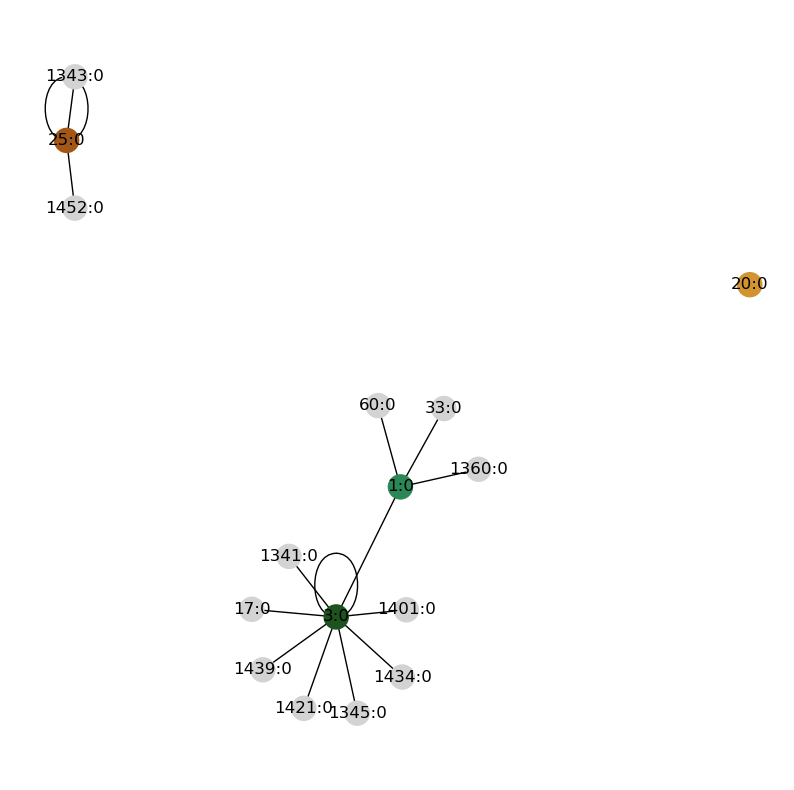

In [ ]:
cluster_1_gene_id = genes_df[(genes_df.cluster_id == 1) & (genes_df.genome_id == genome_id)].index[0]
cluster_3_gene_id = genes_df[(genes_df.cluster_id == 3) & (genes_df.genome_id == genome_id)].index[0]
cluster_25_gene_id = genes_df[(genes_df.cluster_id == 3) & (genes_df.genome_id == genome_id)].index[0]

contacts_df[contacts_df.name.str.contains(cluster_1_gene_id)].name.nunique()
contacts_df[contacts_df.name.str.contains(cluster_1_gene_id)]

seq_to_gene_id_map = genes_df.reset_index(names='gene_id').set_index('seq').gene_id.to_dict()
gene_id_to_cluster_id_map = genes_df.cluster_id.to_dict()

contacts_df['gene_id_0'] = contacts_df.seq_0.map(seq_to_gene_id_map)
contacts_df['gene_id_1'] = contacts_df.seq_1.map(seq_to_gene_id_map)
contacts_df['cluster_id_0'] = contacts_df.gene_id_0.map(gene_id_to_cluster_id_map)
contacts_df['cluster_id_1'] = contacts_df.gene_id_1.map(gene_id_to_cluster_id_map)
contacts_df['contact_id'] = contacts_df.apply(get_contact_id, axis=1)


palette = dict()
palette = {f'{cluster_id}':'lightgray' for cluster_id in genes_df.cluster_id.astype(int).unique()}
# palette.update({cluster_id:'gray' for cluster_id in level_2_conserved_cluster_ids})
# palette.update({cluster_id:'black' for cluster_id in level_1_conserved_cluster_ids})
# palette.update({cluster_id:'gray' for cluster_id in level_3_conserved_cluster_ids})
palette.update({'1':"#2B8756", '3':"#1C531E", '2':"#86C589", '6':"#91C449", '20':"#D19431", '25':"#A25716"})

graph = get_contact_graph(contacts_df, min_num_models=3, min_contact_prob=0, node_ids=['1:0', '20:0', '25:0', '3:0'])
plot_contact_graph(graph, pos=nx.spring_layout(graph, k=0.3), palette=palette)



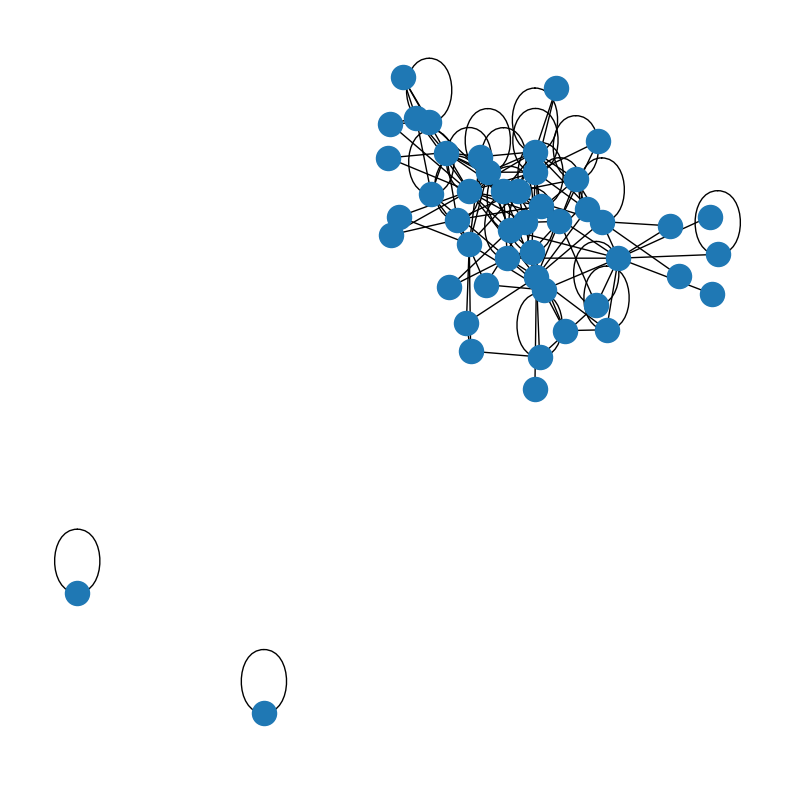

In [ ]:
graph = get_contact_graph(contacts_df)

fig, ax = plt.subplots(figsize=(10, 10))

pos = nx.spring_layout(graph, k=0.2)
nx.draw_networkx_nodes(graph, pos=pos)
nx.draw_networkx_edges(graph, pos=pos, edge_color='black')

for _, spine in ax.spines.items():
    spine.set_visible(False)

plt.show()





In [ ]:
# if not os.path.exists('analysis-1-ppi_data.json'):
    
#     outputs = [AlphaFoldOutput(path) for path in output_dirs if os.path.exists(path)]

#     data = list()
#     for output in outputs:
#         contact_probs_df = output.get_contact_probs(models=[output.best_model])
#         paes_df =  output.get_paes(models=[output.best_model])
#         chain_ids = ['A', 'B']

#         idxs, idxs_shifted = get_interface_idxs(contact_probs_df, chain_ids=chain_ids, shift=True)
#         idxs = [idxs[chain_ids[0]], idxs[chain_ids[1]]]

#         data_ = {'name':output.name}
#         data_['iptm'] = np.mean(list(output.get_iptms().values()))
#         data_['idxs'] = idxs
#         data_['idxs_shifted'] = [idxs_shifted[chain_ids[0]], idxs_shifted[chain_ids[1]]]
#         data_['num_contacts'] = len(idxs[0])
#         data_['pae'] = [paes_df.iloc[i, j] for i, j in zip(*idxs)]
#         data_['contact_probs'] = [contact_probs_df.iloc[i, j] for i, j in zip(*idxs)]
#         data.append(data_)

#     with open('analysis-1-ppi_data.json', 'wb') as f:
#         f.write(orjson.dumps(data, default=default))

# else:
#     with open('analysis-1-ppi_data.json', 'r') as f:
#         data = json.load(f)

# data = [data_ for data_ in data if (data_['num_contacts'] > 0)]
# print(f'Loaded data for {len(data)} AlphaFold co-folds with predicted contacts.')


In [ ]:
# Jack said that looking at the ipTM is not super informative; there could be a valid protein-protein interaction, but low ipTM due to disordered or low-
# confidence regions. Instead, it would be worth looking at the PAE for residues on different monomers. Any error < 10 A could be worth considering as a potential contact. 

# What would be a good potential statistic for evaluating the likelihood of a protein-protein contact? Want to evaluate both (1) predicted distance and (2) PAE. 
# There is also an output called contact_probs, which is based on a seperate output head in the model (i.e. not the pLDDT or PAE head). This is discussed in the 
# supplement of Jumper et. al. 2021. 

# TODO: Take some notes on this, I don't know if I completely understand. 
# Why isn't PAE symmetric? Asymmetry can arise due to differences in the stability of the selected reference frame. 
# The PAE asks "Asuming this residue is correctly located, how wrong is the other one likely to be?"

In [ ]:
# names = list()
# ALPHAFOLD_INPUT_DIR = '../data/genes/alphafold/af_input/'
# ALPHAFOLD_OUTPUT_DIR = '../data/genes/alphafold/af_output/'

# for genome_id, df in genes_df[genes_df.cluster_id.isin([1, 3])].groupby('genome_id'):

#     for pair in itertools.combinations(df.reset_index(names='gene_id').to_dict(orient='records'), 2):
#         name = pair[0]['alphafold_id'].replace('1mer', '6mer') + '-' + pair[1]['alphafold_id'].replace('1mer', '6mer') + '-mg_atp'
#         names.append(name)

#         gene_ids = [pair[0]['gene_id'], pair[1]['gene_id']]
#         seqs = [pair[0]['seq'], pair[1]['seq']]

#         msas = dict()
#         msas['unpaired'] = get_msas_unpaired(gene_ids)

#         file = AlphaFoldInputFile(name, dialect='alphafoldserver', num_seeds=1, version=1)

#         for gene_id, seq in zip(gene_ids, seqs):
#             file.add_seq(seq, paired_msa=msas['paired'][gene_id], unpaired_msa=msas['unpaired'][gene_id], n=6)
#         file.add_atp(n=6)
#         file.add_mg(n=6)

#         file.write(os.path.join(ALPHAFOLD_INPUT_DIR, f'{name}.json'))



In [ ]:
# It seems as though the cluster_1-cluster_3 contact is only predicted highly with the cluster_3 monomer. But is this a failing of AlphaFold?
# Do the contacting residues differ between the monomer predictions and the multimer predictions (i.e. does cluster_3 multimerizing block 
# the preferred interface for cluster_1 and cluster_3)?

In [ ]:
# def get_msas_paired(gene_ids:list, dir_path:str=MMSEQS_DIR):
#     '''Construct paired MSAs using the specified gene IDs as queries. This is done by:
#         (1) Loading the unpaired MSA for each query gene ID. 
#         (2) Filtering each unpaired MSA to include only genes from genomes which are represented in both, i.e. contain identified homologs of each query sequence. 
#         (3) Sorting the MSAs alphabetically by gene ID (ensuring the query is still the first entry) so that rows correspond.
        
#     :param gene_ids: The IDs of the genes to construct paired MSAs for. These should all be from the same genome.   
#     :param dir_path: The path to the directory where the MSAs are stored. This function assumes the a3m files have names matching the gene ID of the query 
#         sequence. 
#     '''
#     assert len(set([get_genome_id(gene_id) for gene_id in gene_ids])) == 1, 'get_msas_paired: Expected all genes to be from the same genome.'

#     paths = {gene_id:os.path.join(dir_path, f'{gene_id}.a3m') for gene_id in gene_ids}
#     msas = {gene_id:FASTAFile.from_file(path).to_df().reset_index(names='gene_id') for gene_id, path in paths.items()}
#     msas = {gene_id:df.assign(genome_id=df.gene_id.apply(get_genome_id)) for gene_id, df in msas.items()}

#     genome_ids = None
#     for _, df in msas.items(): # Get all genome IDs which have a representative for all chains. 
#         genome_ids = df.genome_id.unique() if (genome_ids is None) else np.intersect1d(genome_ids, df.genome_id.unique())
    
#     if len(genome_ids) < 2:
#         # If there are two few genome IDs, the paired MSA will just contain the genes from the query genome (but do not want it to throw an error). 
#         print('get_msas_paired: Too few paired sequences for a proper paired MSA.')

#     sort = lambda df : pd.concat([df.iloc[:1], df.iloc[1:].sort_values('gene_id')]) # Sort a DataFrame by genome ID, while holding the query row fixed.
#     msas = {gene_id:sort(df[df.genome_id.isin(genome_ids)].copy()) for gene_id, df in msas.items()}
    
#     return {gene_id:str(FASTAFile.from_df(df.set_index('gene_id'))) for gene_id, df in msas.items()}
